TEMPLATE_AGROCOMPUTAÇÃO_INTERPOLAÇÃO_29/04/2026

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


IMPORTAR_DADOS

In [7]:
area_agricola = pd.read_csv('AREA_AGRICOLA.csv', encoding='latin1', sep=';')
area_agricola

,Municipio,Codigo,Total2020 (ha),Algodão herbáceo (em caroço),Alho,Amendoim (em casca),Arroz (em casca),Aveia (em grão),Batatadoce,Batatainglesa,...,Mamona (baga),Mandioca,Melancia,Melão,Milho (em grão),Rami (fibra),Soja (em grão),Sorgo (em grão),Tomate,Trigo (em grão)
0,Adamantina,3500105,12276,0,0,200,0,0,0,0,...,0,10,10,0,200,0,500,0,7,0
1,Adolfo,3500204,6696,0,0,1100,0,0,0,0,...,0,0,0,0,85,0,400,0,96,0
2,Aguaí,3500303,19880,145,0,0,0,0,0,0,...,0,190,0,0,5000,0,3000,0,45,0
3,Águas da Prata,3500402,680,0,0,0,0,0,0,50,...,0,0,0,0,600,0,0,0,0,0
4,Águas de Lindóia,3500501,56,0,0,0,0,0,0,0,...,0,1,0,0,50,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,Votorantim,3557006,841,0,0,0,0,0,0,0,...,0,6,0,0,430,0,405,0,0,0
638,Votuporanga,3557105,12640,0,0,0,0,0,0,0,...,0,40,0,0,200,0,300,0,0,0
639,Zacarias,3557154,9666,0,0,400,0,0,0,0,...,0,0,0,0,680,0,500,50,0,0
640,Chavantes,3557204,14088,0,0,0,0,0,0,0,...,0,20,0,0,2098,0,2419,10,0,0


In [30]:
area_agricola = area_agricola.rename(columns={
    'Soja (em grão)': 'Soja',
    'Milho (em grão)': 'Milho',
    'Mandioca': 'Mandioca'
})

Opção para renomear todas as colunas de uma vez:
area_agricola.columns = (
    area_agricola.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
    .str.replace('ã', 'a')
    .str.replace('ç', 'c')
)

In [39]:
area_agricola.columns

Index(['Municipio', 'Codigo', 'Total2020 (ha)', 'Algodão herbáceo (em caroço)',
       'Alho', 'Amendoim (em casca)', 'Arroz (em casca)', 'Aveia (em grão)',
       'Batatadoce', 'Batatainglesa', 'Canadeaçúcar', 'Cana para forragem',
       'Cebola', 'Centeio (em grão)', 'Cevada (em grão)', 'Ervilha (em grão)',
       'Fava (em grão)', 'Feijão (em grão)', 'Fumo (em folha)',
       'Girassol (em grão)', 'Juta (fibra)', 'Linho (semente)',
       'Malva (fibra)', 'Mamona (baga)', 'Mandioca', 'Melancia', 'Melão',
       'Milho', 'Rami (fibra)', 'Soja', 'Sorgo (em grão)', 'Tomate',
       'Trigo (em grão)'],
      dtype='object')

In [8]:
# Caminho do shapefile (.shp)
shapefile_path = "/home/fabricia/Documentos/usados_analise_dados/Agrocomputacao/aula_mapas_II/Bases_de_Dados/Sao_Paulo.shp"

In [9]:
# Ler o shapefile
gdf = gpd.read_file(shapefile_path)

In [14]:
# Visualizar primeiras linhas
gdf.head(3)

,OBJECTID,codigo,nome,UF,nome1968,codmicro,micro,codmeso,nom_meso,Nome1970,Cod1970,UF1970,geometry
0,1,3540408,Populina,São Paulo,Populina,225,Alta Araraquarense de Fernandópolis,55.0,Alta e Média Araraquarense,Populina,3540408.0,35,"POLYGON ((-50.61603 -19.86022, -50.60636 -19.8..."
1,2,3518008,Guarani d'Oeste,São Paulo,Guarani d'Oeste,225,Alta Araraquarense de Fernandópolis,55.0,Alta e Média Araraquarense,Guarani d'Oeste,3518008.0,35,"POLYGON ((-50.454 -19.78453, -50.41664 -19.799..."
2,3,3535903,Paranapuã,São Paulo,Paranapuã,225,Alta Araraquarense de Fernandópolis,55.0,Alta e Média Araraquarense,Paranapuã,3535903.0,35,"POLYGON ((-50.61603 -19.86022, -50.6087 -19.87..."


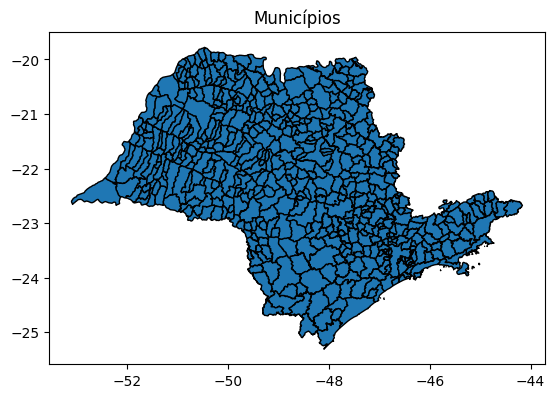

In [11]:
gdf.plot(edgecolor='black')

plt.title("Municípios")
plt.show()

In [13]:
gdf.columns

Index(['OBJECTID', 'codigo', 'nome', 'UF', 'nome1968', 'codmicro', 'micro',
       'codmeso', 'nom_meso', 'Nome1970', 'Cod1970', 'UF1970', 'geometry'],
      dtype='object')

In [33]:
# padronizar código
gdf['codigo'] = gdf['codigo'].astype(int)
area_agricola['Codigo'] = area_agricola['Codigo'].astype(int)

In [16]:
print(gdf.crs)

EPSG:4674


In [17]:
gdf = gdf.to_crs(epsg=4326)

In [18]:
gdf['centroid'] = gdf.geometry.representative_point()

In [34]:
# merge
gdf = gdf.merge(area_agricola, left_on='codigo', right_on='Codigo')

In [35]:

def mapa_interpolado(gdf, coluna):

    # remover NaN
    df = gdf[['lon','lat',coluna]].dropna()

    x = df['lon'].values
    y = df['lat'].values
    z = df[coluna].values

    grid_x, grid_y = np.mgrid[
        x.min():x.max():300j,
        y.min():y.max():300j
    ]

    grid_z = griddata((x, y), z, (grid_x, grid_y), method='cubic')

    fig, ax = plt.subplots(figsize=(10,8))

    im = ax.imshow(
        grid_z.T,
        extent=(x.min(), x.max(), y.min(), y.max()),
        origin='lower'
    )

    gdf.boundary.plot(ax=ax, color='black', linewidth=0.2)

    plt.colorbar(im, label=coluna)
    plt.title(f'Interpolação - {coluna}')

    plt.show()

<Axes: >

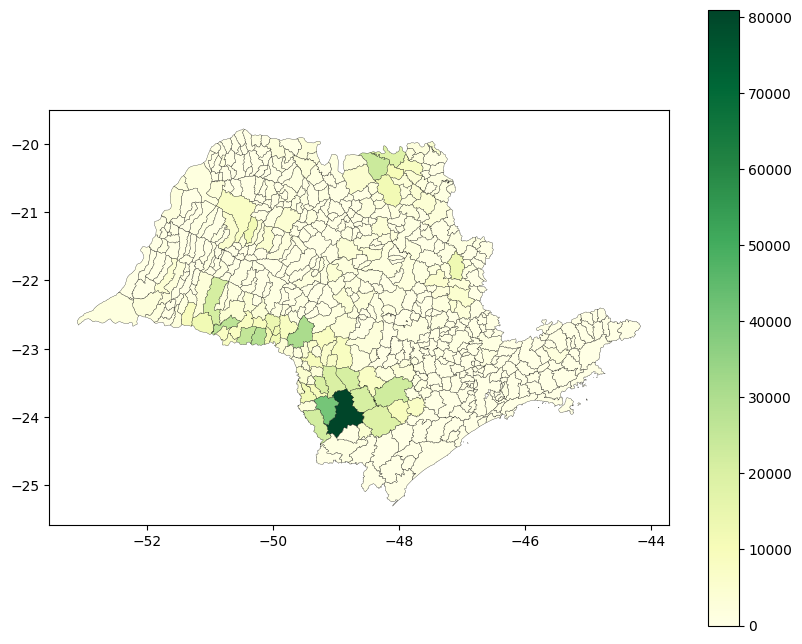

In [36]:
gdf.plot(
    column='Soja',
    cmap='YlGn',
    legend=True,
    figsize=(10,8),
    edgecolor='black',
    linewidth=0.2
)

In [38]:
gdf.Soja.unique()

array([  200,    30,   890,     0,  2466,  2600,   120,   400,  4500,
        2190,  1300,    70, 18150,   600,    90,    80,  1916,  2100,
          20, 23500,   680,   640,  2675,   300,  2000,  1600,   350,
        8407,  1500,   130,  1200,  1150,  5072, 10183,  1000,  1340,
        4218,   900,   250,  3189, 11855,   450,  2558,  1800,   150,
         220,  1670,   800,  1100,  4124,  7400,    50,  1116,   290,
        3800,  2350,    58,   340,   500,   100,    85,   305,   170,
         441,  2240,   939,   850,  1320,  4200,  5150,   590,   110,
       11816,  3700,  3670,   620,   700,  2050,   215,    40,  4800,
          83,   280,  2200,  2500,  2245,   612,  1210,  1400,   395,
        3500,   325,   270,   160,   498,   480,   210,    10,   430,
        4391,   520, 12800,  2300,  1650,  4000,  3000,   140,    45,
        5500, 21500,   986,  1550,   122,   351,   230,  3562,  1254,
         727,  1425,  5000,  2800,  2834,    97,   924,  3200,  1593,
        9000,   180,

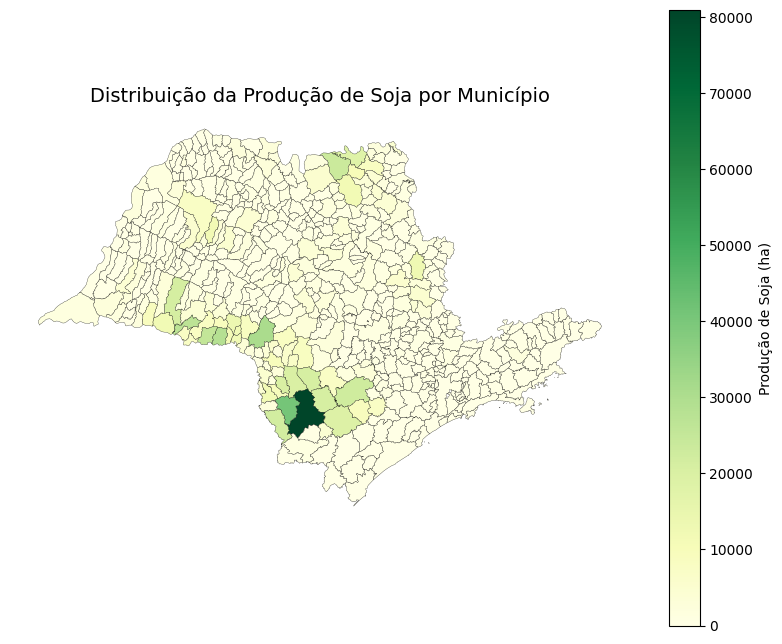

In [40]:

fig, ax = plt.subplots(figsize=(10,8))

gdf.plot(
    column='Soja',
    cmap='YlGn',
    legend=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.2,
    legend_kwds={
        'label': "Produção de Soja (ha)",
        'orientation': "vertical"
    }
)

ax.set_title('Distribuição da Produção de Soja por Município', fontsize=14)
ax.axis('off')

plt.show()